# 🔬 UCFace: Uncertainty-Aware Face Embedding With Contrastive Learning

**Paper:** *Uncertainty-Aware Face Embedding With Contrastive Learning for Open-Set Evaluation*  
**Published in:** IEEE Transactions on Information Forensics and Security, Vol. 19, 2024  
**Authors:** Kyeongjin Ahn, Seungeon Lee, Sungwon Han, Cheng Yaw Low, Meeyoung Cha

---

## 📖 What This Notebook Implements

This notebook provides a **complete, runnable M.Tech research implementation** of UCFace,
covering the paper's core contributions:

1. **ArcFace baseline** — additive angular margin softmax loss  
2. **Feature-norm uncertainty** — using L2-norm of embeddings as an image quality proxy  
3. **vMF-inspired probabilistic representation** — treating each anchor as a distribution on the hypersphere  
4. **Uncertainty-aware supervised contrastive loss** — InfoNCE with vMF-based similarity  
5. **Combined loss** — `L_total = L_arcface + λ * L_uncertainty`

### 🧠 Key Intuition

> A **low-quality** (blurry, occluded) face image has **low feature norm → high uncertainty**,  
> so its contribution to the contrastive loss is down-weighted automatically.
> A **high-quality** image has **high feature norm → low uncertainty**,  
> giving it stronger pull/push forces in the embedding space.

### 🚀 Compatible Environments
- Lightning AI Studio  
- Google Colab (GPU runtime)  
- Kaggle Notebook (GPU)

---

## 1. 📦 Install Dependencies

In [ ]:
# Install all required packages
# pytorch-lightning handles training boilerplate
# torchmetrics provides standard metrics
# scikit-learn is needed for t-SNE and evaluation

!pip install pytorch-lightning>=2.0.0 torchmetrics scikit-learn matplotlib seaborn --quiet

# Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f'✅ GPU detected: {result.stdout.strip()}')
else:
    print('⚠️  No GPU detected — training will be slow on CPU. Switch to GPU runtime!')

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

zsh:1: 2.0.0 not found
✅ GPU detected: NVIDIA L40S, 46068 MiB
PyTorch version : 2.8.0+cu128
CUDA available  : True
GPU             : NVIDIA L40S
VRAM            : 47.7 GB


## 2. 📥 Imports

We import everything needed upfront so all cells below can run independently.

In [4]:
!pip install seaborn

In [ ]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')

# ── Numerical / plotting ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize as sk_normalize

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

# ── Torchvision ───────────────────────────────────────────────────────────────
import torchvision
import torchvision.transforms as T
from torchvision import models
from torchvision.datasets import ImageFolder

# ── PyTorch Lightning ─────────────────────────────────────────────────────────
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    LearningRateMonitor,
    EarlyStopping,
)
from pytorch_lightning.loggers import TensorBoardLogger

# ── Reproducibility seed ──────────────────────────────────────────────────────
pl.seed_everything(42, workers=True)
print('✅ All imports successful.')

Seed set to 42


✅ All imports successful.


## 3. ⚙️ Configurations

All hyperparameters from the paper are collected here in a single config object.  
Modify only this cell to run different experiments.

| Hyperparameter | Value | Source |
|---|---|---|
| `embedding_dim` | 512 | backbone output |
| `proj_dim` | 128 | projection head |
| `arc_margin` | 0.5 | ArcFace paper |
| `arc_scale` | 64 | ArcFace paper |
| `temperature τ` | 0.8 | UCFace Table VI |
| `lambda λ` | 1.0 | UCFace Table VIII |
| `lr` | 1e-4 | UCFace §IV-A |
| `batch_size` | 64 | UCFace §IV-A |

In [3]:
class Config:
    """Central configuration object — edit values here to run ablations."""

    # ── Dataset ────────────────────────────────────────────────────────────────
    DATA_ROOT       = './dataset'          # root folder (train/ and val/ sub-dirs)
    IMAGE_SIZE      = 112                  # standard face recognition input size
    NUM_WORKERS     = 4                    # DataLoader workers

    # ── Architecture ──────────────────────────────────────────────────────────
    EMBEDDING_DIM   = 512                  # backbone embedding dimension d_f
    PROJ_DIM        = 128                  # projection head output dim d_g
    DROPOUT         = 0.5                  # dropout inside model head

    # ── ArcFace ────────────────────────────────────────────────────────────────
    ARC_MARGIN      = 0.5                  # angular margin m
    ARC_SCALE       = 64.0                 # feature scale s

    # ── UCFace contrastive ─────────────────────────────────────────────────────
    TEMPERATURE     = 0.8                  # τ — default from paper Table VI
    LAMBDA          = 1.0                  # λ — weight of L_U in L_total
    EPS             = 1e-8                 # numerical stability

    # ── Training ───────────────────────────────────────────────────────────────
    BATCH_SIZE      = 64                   # adjust if OOM: try 32 or 16
    NUM_EPOCHS      = 5
    LR              = 1e-4                 # Adam learning rate for ResNet-50
    LR_DECAY_EPOCHS = 10                   # cosine restart period
    WEIGHT_DECAY    = 5e-4
    GRAD_CLIP       = 1.0                  # prevent exploding gradients
    ACCUM_BATCHES   = 2                    # gradient accumulation steps

    # ── Logging / checkpoints ──────────────────────────────────────────────────
    LOG_DIR         = './logs'
    CKPT_DIR        = './checkpoints'
    EXP_NAME        = 'UCFace_ResNet50'

    # ── Precision (16-bit mixed for memory efficiency) ─────────────────────────
    PRECISION       = '16-mixed'          # set '32-true' if NaN issues persist


cfg = Config()

# ── Auto-detect number of classes (updated after dataset is loaded) ────────────
cfg.NUM_CLASSES = None   # will be set in Section 4

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Config ready. BATCH_SIZE={cfg.BATCH_SIZE}, τ={cfg.TEMPERATURE}, λ={cfg.LAMBDA}')

Device: cuda
Config ready. BATCH_SIZE=64, τ=0.8, λ=1.0


## 4. 🗂️ Dataset Preparation

### Expected folder structure
```
dataset/
├── train/
│   ├── person_001/
│   │   ├── img001.jpg
│   │   └── img002.jpg
│   └── person_002/
│       └── img001.jpg
└── val/
    ├── person_001/
    └── person_002/
```

**Recommended datasets:**
- [CASIA-WebFace](https://github.com/happynear/AMSoftmax) — 10,575 identities, 494,414 images  
- [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) — 10,177 identities, 202,599 images

The cell below also creates a **synthetic demo dataset** so you can run the notebook end-to-end without downloading anything.

In [ ]:
# import os
# import shutil
# import random
# from tqdm import tqdm

# source_dir = "/teamspace/studios/this_studio/celeba_by_identity"

# train_dir = "/teamspace/studios/this_studio/dataset/train"
# val_dir = "/teamspace/studios/this_studio/dataset/val"

# os.makedirs(train_dir, exist_ok=True)
# os.makedirs(val_dir, exist_ok=True)

# split_ratio = 0.8

# identities = os.listdir(source_dir)

# for identity in tqdm(identities):

#     identity_path = os.path.join(source_dir, identity)

#     if not os.path.isdir(identity_path):
#         continue

#     images = os.listdir(identity_path)

#     # skip identities with very few images
#     if len(images) < 2:
#         continue

#     random.shuffle(images)

#     split_index = int(len(images) * split_ratio)

#     train_images = images[:split_index]
#     val_images = images[split_index:]

#     # create identity folders
#     train_identity_dir = os.path.join(train_dir, identity)
#     val_identity_dir = os.path.join(val_dir, identity)

#     os.makedirs(train_identity_dir, exist_ok=True)
#     os.makedirs(val_identity_dir, exist_ok=True)

#     # copy train images
#     for img in train_images:

#         src = os.path.join(identity_path, img)
#         dst = os.path.join(train_identity_dir, img)

#         shutil.copy2(src, dst)

#     # copy val images
#     for img in val_images:

#         src = os.path.join(identity_path, img)
#         dst = os.path.join(val_identity_dir, img)

#         shutil.copy2(src, dst)

# print("Train/Validation split completed!")

  0%|          | 0/10177 [00:00<?, ?it/s]

  0%|          | 29/10177 [00:23<2:19:12,  1.22it/s]


KeyboardInterrupt: 

In [ ]:
import os

train_dir = "/teamspace/studios/this_studio/dataset/train"
val_dir = "/teamspace/studios/this_studio/dataset/val"

train_folders = [
    f for f in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, f))
]

val_folders = [
    f for f in os.listdir(val_dir)
    if os.path.isdir(os.path.join(val_dir, f))
]

print("Train identities:", len(train_folders))
print("Validation identities:", len(val_folders))

Train identities: 10133
Validation identities: 10133


In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    "/teamspace/studios/this_studio/dataset/train"
)

val_dataset = ImageFolder(
    "/teamspace/studios/this_studio/dataset/val"
)

print("Train classes:", len(train_dataset.classes))
print("Validation classes:", len(val_dataset.classes))

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Train classes: 10133
Validation classes: 10133
Train images: 159377
Validation images: 43395


In [ ]:
import torchvision.transforms.functional as TF
from PIL import Image

# ── Synthetic demo dataset ─────────────────────────────────────────────────────
# Creates N_CLASSES fake identities with N_IMGS_PER_CLASS images each.
# Replace with your real dataset path in cfg.DATA_ROOT.

N_CLASSES        = 100    # number of synthetic identities
N_IMGS_PER_CLASS = 20     # images per identity
USE_SYNTHETIC    = not Path(cfg.DATA_ROOT).exists()  # auto-fallback

def create_synthetic_dataset(root: str, n_classes: int = 100,
                              n_per_class: int = 20, img_size: int = 112):
    """Creates random RGB images organized into class folders."""
    for split in ['train', 'val']:
        n = n_per_class if split == 'train' else max(4, n_per_class // 4)
        for cls_id in range(n_classes):
            folder = Path(root) / split / f'id_{cls_id:04d}'
            folder.mkdir(parents=True, exist_ok=True)
            for img_id in range(n):
                img_path = folder / f'{img_id:04d}.jpg'
                if not img_path.exists():
                    # Create a unique color per class + slight noise
                    base_color = [
                        int(255 * ((cls_id * 37 + c * 97) % 256) / 255)
                        for c in range(3)
                    ]
                    arr = np.full((img_size, img_size, 3), base_color, dtype=np.uint8)
                    noise = np.random.randint(-30, 30, arr.shape, dtype=np.int16)
                    arr = np.clip(arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
                    Image.fromarray(arr).save(img_path)
    print(f'✅ Synthetic dataset created at {root} '
          f'({n_classes} classes × {n_per_class} train imgs)')


if USE_SYNTHETIC:
    print('⚠️  Real dataset not found — generating synthetic demo data…')
    create_synthetic_dataset(cfg.DATA_ROOT, N_CLASSES, N_IMGS_PER_CLASS, cfg.IMAGE_SIZE)
else:
    print(f'✅ Using existing dataset at {cfg.DATA_ROOT}')

# ── Count classes ─────────────────────────────────────────────────────────────
train_root = Path(cfg.DATA_ROOT) / 'train'
cfg.NUM_CLASSES = len(list(train_root.iterdir()))
print(f'Number of identities (classes): {cfg.NUM_CLASSES}')

✅ Using existing dataset at ./dataset
Number of identities (classes): 10133


## 5. 🔄 Data Augmentation

Following the UCFace paper, each image is augmented **twice** to create positive pairs for contrastive learning.  
Augmentations include random horizontal flip, color jitter, and Gaussian blur — standard for face contrastive learning.

In [7]:
# ── Augmentation pipeline ──────────────────────────────────────────────────────

# Strong augmentation for contrastive views
CONTRASTIVE_TRANSFORM = T.Compose([
    T.RandomResizedCrop(cfg.IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=int(0.1 * cfg.IMAGE_SIZE) | 1, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # normalize to [-1,1]
])

# Standard evaluation transform (no augmentation)
EVAL_TRANSFORM = T.Compose([
    T.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class UCFaceDataset(Dataset):
    """
    Wraps an ImageFolder and returns TWO augmented views of each image
    for the contrastive loss, plus the class label for ArcFace.

    Returns:
        view1  : first augmented view  (Tensor C×H×W)
        view2  : second augmented view (Tensor C×H×W)
        label  : integer class index
    """

    def __init__(self, root: str, transform):
        self.base = ImageFolder(root=root)
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_pil, label = self.base[idx]   # PIL image
        view1 = self.transform(img_pil)   # first augmented view
        view2 = self.transform(img_pil)   # second augmented view (different due to randomness)
        return view1, view2, label


print('✅ Augmentation transforms and UCFaceDataset class defined.')

✅ Augmentation transforms and UCFaceDataset class defined.


## 6. 📊 DataLoaders

The paper uses:
- Batch size **64** for classification (ArcFace) loss  
- Each batch for contrastive learning contains 2 augmented views per sample  

We handle both within a single unified DataLoader here for simplicity.

In [8]:
def build_dataloaders(cfg):
    """Build train and validation DataLoaders."""

    train_ds = UCFaceDataset(
        root=str(Path(cfg.DATA_ROOT) / 'train'),
        transform=CONTRASTIVE_TRANSFORM,
    )
    val_ds = UCFaceDataset(
        root=str(Path(cfg.DATA_ROOT) / 'val'),
        transform=EVAL_TRANSFORM,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,    # important: contrastive loss needs full batches
        persistent_workers=cfg.NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
        persistent_workers=cfg.NUM_WORKERS > 0,
    )

    return train_loader, val_loader


train_loader, val_loader = build_dataloaders(cfg)

# ── Quick sanity check ─────────────────────────────────────────────────────────
v1, v2, lbl = next(iter(train_loader))
print(f'Train batches   : {len(train_loader)}')
print(f'Val   batches   : {len(val_loader)}')
print(f'view1 shape     : {v1.shape}')   # (B, 3, 112, 112)
print(f'view2 shape     : {v2.shape}')   # (B, 3, 112, 112)
print(f'labels shape    : {lbl.shape}')  # (B,)
print(f'Label range     : [{lbl.min().item()}, {lbl.max().item()}]')

Train batches   : 2490
Val   batches   : 679
view1 shape     : torch.Size([64, 3, 112, 112])
view2 shape     : torch.Size([64, 3, 112, 112])
labels shape    : torch.Size([64])
Label range     : [148, 9945]


## 7. 📐 ArcFace Loss

### Mathematical Formulation

ArcFace adds an **angular margin** `m` to the cosine angle between the embedding  
and the correct class weight:

$$
\mathcal{L}_i = -\log \frac{e^{s \cos(\theta_{y_i} + m)}}{e^{s \cos(\theta_{y_i} + m)} + \sum_{j \neq y_i} e^{s \cos \theta_j}}
$$

where:
- `s = 64` is the feature scale  
- `m = 0.5` is the angular margin  
- Both **embeddings** and **weight vectors** are L2-normalized (so everything lives on a hypersphere)

In [9]:
class ArcFaceLoss(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss.

    Reference: Deng et al., CVPR 2019.

    Args:
        in_features   : embedding dimension (e.g. 512)
        num_classes   : total number of identities in training set
        margin        : angular margin m in radians (default 0.5 ≈ 28.6°)
        scale         : feature scaling factor s (default 64)
    """

    def __init__(self, in_features: int, num_classes: int,
                 margin: float = 0.5, scale: float = 64.0):
        super().__init__()
        self.in_features  = in_features
        self.num_classes  = num_classes
        self.margin       = margin
        self.scale        = scale

        # Learnable weight matrix W ∈ R^{num_classes × in_features}
        # Each row is the prototype of one identity
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

        # Pre-compute trig values for the margin
        self.cos_m  = math.cos(margin)
        self.sin_m  = math.sin(margin)
        # Safety threshold: cos(π - m) to handle cos_theta + margin > π
        self.th     = math.cos(math.pi - margin)
        self.mm     = math.sin(math.pi - margin) * margin

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Args:
            embeddings : (B, in_features) — raw backbone embeddings
            labels     : (B,) — integer class indices
        Returns:
            Scalar loss value
        """
        # L2-normalise both embeddings and weights so their dot product = cosine similarity
        emb_norm = F.normalize(embeddings, p=2, dim=1)             # (B, d)
        W_norm   = F.normalize(self.weight,  p=2, dim=1)           # (C, d)

        # Cosine similarity: cos_theta[i,j] = cos(angle between emb_i and prototype_j)
        cos_theta = emb_norm @ W_norm.T                            # (B, C)
        # Clamp for numerical safety
        cos_theta = cos_theta.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        # sin_theta = sqrt(1 - cos^2(theta)) — from trig identity
        sin_theta = torch.sqrt(1.0 - cos_theta.pow(2))

        # cos(theta + m) = cos_theta * cos_m - sin_theta * sin_m  (angle addition formula)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m

        # Boundary fix: if (theta + m) > π, fall back to cos_theta - mm
        cos_theta_m = torch.where(
            cos_theta > self.th,
            cos_theta_m,
            cos_theta - self.mm
        )

        # One-hot mask to select the ground-truth logit for each sample
        one_hot = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1, 1), 1.0)

        # Replace the ground-truth cosine with the margin-penalised version
        logits = one_hot * cos_theta_m + (1.0 - one_hot) * cos_theta
        logits = logits * self.scale

        loss = F.cross_entropy(logits, labels)
        return loss


# ── Quick unit test ────────────────────────────────────────────────────────────
_af = ArcFaceLoss(in_features=512, num_classes=100)
_emb = torch.randn(8, 512)
_lbl = torch.randint(0, 100, (8,))
_loss = _af(_emb, _lbl)
assert not _loss.isnan(), 'ArcFace produced NaN!'
print(f'✅ ArcFace unit test passed. Loss = {_loss.item():.4f}')

✅ ArcFace unit test passed. Loss = 37.7903


## 8. 🎯 Uncertainty-Aware Contrastive Loss (UCFace Core)

### Theory

**vMF distribution on the hypersphere:**

$$
\text{vMF}(\mathbf{x}; \boldsymbol{\mu}, \kappa) = C(\kappa) \cdot \exp(\kappa \boldsymbol{\mu}^\top \mathbf{x})
$$

Each anchor sample `i` is represented as a vMF distribution:
- **Mean direction** `μ = ẑᵢ = zᵢ / ‖zᵢ‖` (unit vector)
- **Concentration** `κ = ‖zᵢ‖` (feature norm)

High feature norm → sharp distribution (low uncertainty)  
Low feature norm → flat distribution (high uncertainty)

**Similarity between anchor i and sample j:**

$$
\text{sim}(\hat{\mathbf{z}}_j, \mathbf{z}_i) = \log V_{\mathbf{z}_i}(\hat{\mathbf{z}}_j) \propto \kappa_i \cdot (\hat{\mathbf{z}}_i^\top \hat{\mathbf{z}}_j)
$$

This is essentially **κᵢ × cosine_similarity(zᵢ, zⱼ)** — the feature norm scales the similarity!

**InfoNCE-based contrastive loss:**

$$
\mathcal{L}_U = -\frac{1}{|P(i)|} \sum_{p \in P(i)} \log \frac{\exp(\text{sim}(\hat{\mathbf{z}}_p, \mathbf{z}_i)/\tau)}{\sum_{j \in B \setminus i} \exp(\text{sim}(\hat{\mathbf{z}}_j, \mathbf{z}_i)/\tau)}
$$

The key: **κᵢ is detached** from gradient flow to prevent the model from gaming the norm.

In [10]:
class UCFaceContrastiveLoss(nn.Module):
    """
    Uncertainty-Aware Contrastive Loss from UCFace (Eq. 18–19 in the paper).

    Treats each anchor as a vMF distribution:
      μ  = L2-normalised projection embedding (ẑᵢ)
      κ  = L2-norm of projection embedding (‖zᵢ‖), DETACHED from graph

    Similarity: sim(ẑⱼ, zᵢ) = κᵢ · cosine_similarity(ẑᵢ, ẑⱼ)

    Args:
        temperature : τ scalar (default 0.8 from paper)
        eps         : small constant for numerical safety
    """

    def __init__(self, temperature: float = 0.8, eps: float = 1e-8):
        super().__init__()
        self.tau = temperature
        self.eps = eps

    def forward(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Args:
            z      : (B, proj_dim) — raw projection head outputs (NOT normalised)
            labels : (B,) — integer identity labels

        Returns:
            Scalar uncertainty-aware contrastive loss
        """
        B = z.size(0)
        device = z.device

        # ── Step 1: Compute feature norms (= κ, concentration parameter) ────────
        # .detach() is CRITICAL — stops training from gaming the norm to reduce loss
        kappa = torch.norm(z, p=2, dim=1, keepdim=True).detach()   # (B, 1)

        # ── Step 2: L2-normalise to get unit direction vectors (= μ) ─────────────
        z_hat = F.normalize(z, p=2, dim=1)                         # (B, proj_dim)

        # ── Step 3: Compute vMF-inspired similarity matrix ───────────────────────
        # cosine_sim[i,j] = ẑᵢᵀ ẑⱼ  (pure cosine, no norm scaling yet)
        cosine_sim = z_hat @ z_hat.T                               # (B, B)
        cosine_sim = cosine_sim.clamp(-1.0 + self.eps, 1.0 - self.eps)

        # sim[i,j] = κᵢ · cosine_sim[i,j]  — κ is ANCHOR-side, hence .detach()
        # Each row i is scaled by the concentration of anchor i
        sim_matrix = kappa * cosine_sim                            # (B, B)

        # ── Step 4: Temperature scaling ──────────────────────────────────────────
        sim_matrix = sim_matrix / self.tau

        # ── Step 5: Build positive / negative masks ──────────────────────────────
        # positive_mask[i,j] = 1 if labels[i] == labels[j] AND i ≠ j
        labels_row = labels.unsqueeze(1)                           # (B, 1)
        labels_col = labels.unsqueeze(0)                           # (1, B)
        positive_mask = (labels_row == labels_col).float()         # (B, B)

        # Exclude self (diagonal) — i is not its own positive
        diag_mask = torch.eye(B, device=device, dtype=torch.bool)
        positive_mask[diag_mask] = 0.0

        # ── Step 6: Numerically stable log-sum-exp denominator ───────────────────
        # Exclude self from denominator (B\{i})
        # We mask by setting self-similarity to -inf before softmax
        sim_for_denom = sim_matrix.clone()
        sim_for_denom[diag_mask] = float('-inf')

        # log-sum-exp of all j ≠ i
        # Shape: (B,) — one log-denominator per anchor
        log_denom = torch.logsumexp(sim_for_denom, dim=1)          # (B,)

        # ── Step 7: InfoNCE loss for each anchor ──────────────────────────────────
        # log p(positive | anchor) = sim(pos, anchor) - log_denom
        # Averaged over all positives for this anchor

        # Number of positives per anchor
        num_positives = positive_mask.sum(dim=1)                   # (B,)

        # For anchors with NO positives in the batch (edge case),
        # skip them (contributes 0 to loss)
        has_positive = num_positives > 0

        # log_numerator[i,j] = sim(ẑⱼ, zᵢ) / τ  for positive j
        log_numerator = sim_matrix                                  # (B, B)

        # Per-anchor loss: -1/|P(i)| * Σ_{p∈P(i)} [log_num - log_denom]
        # Expand log_denom to (B, B) for broadcasting
        log_prob = log_numerator - log_denom.unsqueeze(1)          # (B, B)

        # Mask to keep only positive pairs, sum over positives
        loss_per_anchor = -(log_prob * positive_mask).sum(dim=1)   # (B,)

        # Normalise by number of positives
        loss_per_anchor[has_positive] /= num_positives[has_positive]

        # Final loss: mean over valid anchors
        if has_positive.sum() == 0:
            # Degenerate batch: all singletons — return zero loss
            return torch.tensor(0.0, device=device, requires_grad=True)

        loss = loss_per_anchor[has_positive].mean()

        # ── NaN guard ─────────────────────────────────────────────────────────────
        if loss.isnan() or loss.isinf():
            print('⚠️  UCFace loss is NaN/Inf — returning zero for this step.')
            return torch.tensor(0.0, device=device, requires_grad=True)

        return loss


# ── Unit test ──────────────────────────────────────────────────────────────────
_cl = UCFaceContrastiveLoss(temperature=0.8)
_z  = torch.randn(16, 128)
_lbl = torch.tensor([0,0,1,1,2,2,3,3,4,4,5,5,6,6,7,7])
_loss_cl = _cl(_z, _lbl)
assert not _loss_cl.isnan(), 'Contrastive loss is NaN!'
print(f'✅ UCFace contrastive loss unit test passed. Loss = {_loss_cl.item():.4f}')

✅ UCFace contrastive loss unit test passed. Loss = 3.6961


## 9. 🏗️ Backbone Network

We use a **pretrained ResNet-50** (ImageNet weights) as the backbone `f(·)`.  
The final FC layer is replaced with a custom embedding layer of dimension 512,  
followed by BatchNorm for stability (standard in face recognition).

In [11]:
class FaceBackbone(nn.Module):
    """
    ResNet-50 backbone adapted for face embedding.

    Architecture:
        ResNet-50 (ImageNet pretrained)
        → AvgPool  (2048-dim feature)
        → Linear(2048 → embedding_dim)
        → BatchNorm1d

    The BN layer makes the output distribution more stable;
    it does NOT apply L2-normalisation here — that is done
    inside ArcFace and the contrastive loss.

    Args:
        embedding_dim : output dimension (default 512)
        dropout       : dropout probability before the embedding layer
    """

    def __init__(self, embedding_dim: int = 512, dropout: float = 0.5):
        super().__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Keep everything except the final FC layer
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # up to avgpool

        # Custom embedding head
        self.dropout  = nn.Dropout(p=dropout)
        self.embed_fc = nn.Linear(2048, embedding_dim, bias=False)
        self.embed_bn = nn.BatchNorm1d(embedding_dim)

        # Weight initialisation
        nn.init.xavier_normal_(self.embed_fc.weight)
        nn.init.ones_(self.embed_bn.weight)
        nn.init.zeros_(self.embed_bn.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, 3, H, W) input face images
        Returns:
            r : (B, embedding_dim) face embedding vectors
        """
        feat = self.features(x)            # (B, 2048, 1, 1)
        feat = feat.flatten(1)             # (B, 2048)
        feat = self.dropout(feat)
        r    = self.embed_fc(feat)         # (B, embedding_dim)
        r    = self.embed_bn(r)            # (B, embedding_dim)
        return r


# ── Sanity check ───────────────────────────────────────────────────────────────
_bb = FaceBackbone(embedding_dim=cfg.EMBEDDING_DIM)
_x  = torch.randn(4, 3, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
_r  = _bb(_x)
print(f'✅ Backbone output shape: {_r.shape}  (expected: [4, {cfg.EMBEDDING_DIM}])')
del _bb, _x, _r

✅ Backbone output shape: torch.Size([4, 512])  (expected: [4, 512])


## 10. 🔮 Projection Head

The projection head `g(·)` maps the 512-dim face embedding to a 128-dim space  
for computing the contrastive loss. This is standard in SimCLR / SupCon literature.

> ⚠️ **The projection head is ONLY used during training.**  
> At inference, we discard it and use the raw 512-dim embeddings from the backbone.

In [12]:
class ProjectionHead(nn.Module):
    """
    MLP projection head g(·) mapping embedding → contrastive space.

    From the paper: single fully-connected layer, d_g = 128.
    We add one hidden layer with ReLU for slightly better representation
    (common in SupCon literature).

    Architecture:
        Linear(in_dim → in_dim) → ReLU → Linear(in_dim → proj_dim)

    The output is NOT L2-normalised here.
    Normalisation happens inside UCFaceContrastiveLoss.forward().
    """

    def __init__(self, in_dim: int = 512, proj_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim, bias=False),
            nn.BatchNorm1d(in_dim),
            nn.ReLU(inplace=True),
            nn.Linear(in_dim, proj_dim, bias=False),
        )
        # Init
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)

    def forward(self, r: torch.Tensor) -> torch.Tensor:
        """
        Args:
            r : (B, in_dim) backbone embeddings
        Returns:
            z : (B, proj_dim) projection embeddings
        """
        return self.net(r)


# ── Test ───────────────────────────────────────────────────────────────────────
_ph = ProjectionHead(in_dim=cfg.EMBEDDING_DIM, proj_dim=cfg.PROJ_DIM)
_r  = torch.randn(4, cfg.EMBEDDING_DIM)
_z  = _ph(_r)
print(f'✅ Projection head output: {_z.shape}  (expected: [4, {cfg.PROJ_DIM}])')
del _ph, _r, _z

✅ Projection head output: torch.Size([4, 128])  (expected: [4, 128])


## 11. ⚡ PyTorch Lightning Module

The `UCFaceLightningModule` wraps:
1. **Backbone** `f` — ResNet-50 → 512-dim embedding  
2. **Projection head** `g` — 512 → 128-dim for contrastive learning  
3. **ArcFace classifier** — 512 × num_classes weight matrix  
4. **Combined loss** — `L_total = L_arcface + λ * L_uncertainty`

In [13]:
class UCFaceLightningModule(pl.LightningModule):
    """
    PyTorch Lightning wrapper for the full UCFace model.

    Training flow (per batch):
        view1, view2, labels → backbone f → embeddings r
                             → projection head g → projections z
        L_arcface = ArcFace(r, labels)
        L_uncert  = UCFaceContrastive(z_concat, labels_concat)
        L_total   = L_arcface + λ * L_uncert

    Inference:
        image → backbone f → embedding r  (projection head discarded)
    """

    def __init__(self, cfg):
        super().__init__()
        self.save_hyperparameters({
            'embedding_dim'  : cfg.EMBEDDING_DIM,
            'proj_dim'       : cfg.PROJ_DIM,
            'num_classes'    : cfg.NUM_CLASSES,
            'arc_margin'     : cfg.ARC_MARGIN,
            'arc_scale'      : cfg.ARC_SCALE,
            'temperature'    : cfg.TEMPERATURE,
            'lambda_uc'      : cfg.LAMBDA,
            'lr'             : cfg.LR,
        })
        self.cfg = cfg

        # ── Model components ────────────────────────────────────────────────────
        self.backbone         = FaceBackbone(cfg.EMBEDDING_DIM, cfg.DROPOUT)
        self.proj_head        = ProjectionHead(cfg.EMBEDDING_DIM, cfg.PROJ_DIM)
        self.arcface_loss     = ArcFaceLoss(
            in_features=cfg.EMBEDDING_DIM,
            num_classes=cfg.NUM_CLASSES,
            margin=cfg.ARC_MARGIN,
            scale=cfg.ARC_SCALE,
        )
        self.contrastive_loss = UCFaceContrastiveLoss(
            temperature=cfg.TEMPERATURE,
            eps=cfg.EPS,
        )

        # Logging buffers for visualisation
        self._val_embeddings = []
        self._val_labels     = []
        self._val_norms      = []

    # ── Forward ─────────────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor):
        """Returns backbone embedding r (for inference)."""
        return self.backbone(x)

    def encode_for_contrastive(self, x: torch.Tensor):
        """Returns projection head output z (for contrastive loss during training)."""
        r = self.backbone(x)
        z = self.proj_head(r)
        return r, z

    # ── Training ────────────────────────────────────────────────────────────────
    def training_step(self, batch, batch_idx):
        view1, view2, labels = batch
        B = view1.size(0)

        # ── Encode both views ─────────────────────────────────────────────────
        r1, z1 = self.encode_for_contrastive(view1)
        r2, z2 = self.encode_for_contrastive(view2)

        # ── ArcFace loss on view1 embeddings only ─────────────────────────────
        loss_arc = self.arcface_loss(r1, labels)

        # ── Uncertainty-aware contrastive loss on concatenated views ──────────
        # Concatenate both views → the batch now has 2B samples
        # Each identity appears in 2 positions (views) in this batch,
        # making them natural positives for each other.
        z_concat     = torch.cat([z1, z2], dim=0)          # (2B, proj_dim)
        labels_concat = torch.cat([labels, labels], dim=0) # (2B,)

        loss_uc = self.contrastive_loss(z_concat, labels_concat)

        # ── Combined loss ─────────────────────────────────────────────────────
        loss_total = loss_arc + self.cfg.LAMBDA * loss_uc

        # ── Logging ───────────────────────────────────────────────────────────
        self.log('train/loss_total', loss_total, prog_bar=True,  on_step=True, on_epoch=True)
        self.log('train/loss_arc',   loss_arc,   prog_bar=False, on_step=True, on_epoch=True)
        self.log('train/loss_uc',    loss_uc,    prog_bar=False, on_step=True, on_epoch=True)

        # Log mean feature norm as proxy for image quality
        mean_norm = torch.norm(r1, p=2, dim=1).mean()
        self.log('train/mean_feat_norm', mean_norm, on_step=False, on_epoch=True)

        return loss_total

    # ── Validation ──────────────────────────────────────────────────────────────
    def validation_step(self, batch, batch_idx):
        view1, _, labels = batch   # only need one view for validation

        with torch.no_grad():
            r = self.backbone(view1)              # (B, embedding_dim)
            z = self.proj_head(r)                 # (B, proj_dim)

        # Store for epoch-end analysis
        self._val_embeddings.append(r.cpu())
        self._val_labels.append(labels.cpu())
        self._val_norms.append(torch.norm(r, p=2, dim=1).cpu())

        # ── Validation ArcFace loss ───────────────────────────────────────────
        loss_arc = self.arcface_loss(r, labels)
        loss_uc  = self.contrastive_loss(z, labels)
        loss     = loss_arc + self.cfg.LAMBDA * loss_uc

        self.log('val/loss', loss, prog_bar=True, on_epoch=True)

        # ── Cosine similarity accuracy (simple verification metric) ──────────
        emb_norm   = F.normalize(r, p=2, dim=1)
        cosine_mat = emb_norm @ emb_norm.T                     # (B, B)

        # Compute verification accuracy: positive pairs > negative pairs
        pos_mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        pos_mask.fill_diagonal_(0)
        neg_mask = 1.0 - pos_mask
        neg_mask.fill_diagonal_(0)

        if pos_mask.sum() > 0 and neg_mask.sum() > 0:
            mean_pos_sim = (cosine_mat * pos_mask).sum() / (pos_mask.sum() + 1e-8)
            mean_neg_sim = (cosine_mat * neg_mask).sum() / (neg_mask.sum() + 1e-8)
            self.log('val/mean_pos_cosine', mean_pos_sim, on_epoch=True)
            self.log('val/mean_neg_cosine', mean_neg_sim, on_epoch=True)
            self.log('val/cosine_gap',
                     mean_pos_sim - mean_neg_sim, prog_bar=True, on_epoch=True)

        return loss

    def on_validation_epoch_end(self):
        """Aggregate validation buffers for epoch-level analysis."""
        if self._val_embeddings:
            all_embs  = torch.cat(self._val_embeddings,  dim=0)
            all_norms = torch.cat(self._val_norms,       dim=0)
            self.log('val/mean_feat_norm', all_norms.mean(), on_epoch=True)
            self.log('val/std_feat_norm',  all_norms.std(),  on_epoch=True)

        # Clear buffers
        self._val_embeddings.clear()
        self._val_labels.clear()
        self._val_norms.clear()


# ── Instantiate model ──────────────────────────────────────────────────────────
model = UCFaceLightningModule(cfg)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model created.')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')

✅ Model created.
   Total params    : 30,074,432
   Trainable params: 30,074,432


## 14. 🔧 Optimizer & LR Scheduler

Following the paper:
- **Adam** optimizer with `lr = 1e-4` for ResNet-50  
- **Cosine Annealing** with warm restarts every 10 epochs  
- Gradient clipping at 1.0 to prevent exploding gradients

In [14]:
# The configure_optimizers method is defined INSIDE the LightningModule.
# We patch it here to keep the training logic visible in this cell.

def configure_optimizers(self):
    """
    Adam + CosineAnnealingWarmRestarts as described in the paper.

    Note: ArcFace weight matrix gets 10× higher lr because it is
    randomly initialised while the backbone has pretrained weights.
    """
    backbone_params  = list(self.backbone.parameters())
    proj_params      = list(self.proj_head.parameters())
    arcface_params   = list(self.arcface_loss.parameters())

    optimizer = torch.optim.Adam([
        {'params': backbone_params,  'lr': self.cfg.LR},
        {'params': proj_params,      'lr': self.cfg.LR},
        {'params': arcface_params,   'lr': self.cfg.LR * 10},  # faster convergence for new head
    ], weight_decay=self.cfg.WEIGHT_DECAY)

    # Cosine annealing: decays lr to 0 over T_0 epochs, then restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=self.cfg.LR_DECAY_EPOCHS,
        T_mult=2,
        eta_min=1e-6,
    )

    return {
        'optimizer': optimizer,
        'lr_scheduler': {
            'scheduler': scheduler,
            'interval': 'epoch',
            'monitor': 'val/loss',
        },
    }


# Bind configure_optimizers to the model class
UCFaceLightningModule.configure_optimizers = configure_optimizers
print('✅ Optimizer and scheduler configured (Adam + CosineAnnealingWarmRestarts).')

✅ Optimizer and scheduler configured (Adam + CosineAnnealingWarmRestarts).


## 15. 🛠️ Trainer Setup

We configure the PyTorch Lightning `Trainer` with:
- Mixed precision (FP16) for memory efficiency  
- ModelCheckpoint saving best val loss  
- LearningRateMonitor for TensorBoard  
- EarlyStopping after 10 epochs without improvement

In [15]:
import os
os.makedirs(cfg.LOG_DIR, exist_ok=True)
os.makedirs(cfg.CKPT_DIR, exist_ok=True)

# ── Callbacks ─────────────────────────────────────────────────────────────────
checkpoint_callback = ModelCheckpoint(
    dirpath=cfg.CKPT_DIR,
    filename='ucface-{epoch:02d}-{val/loss:.4f}',
    monitor='val/loss',
    mode='min',
    save_top_k=3,
    save_last=True,
    verbose=True,
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

early_stopping = EarlyStopping(
    monitor='val/loss',
    patience=10,
    mode='min',
    verbose=True,
)

# ── Logger ────────────────────────────────────────────────────────────────────
tb_logger = TensorBoardLogger(
    save_dir=cfg.LOG_DIR,
    name=cfg.EXP_NAME,
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = Trainer(
    max_epochs=cfg.NUM_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    precision=cfg.PRECISION if torch.cuda.is_available() else '32-true',
    callbacks=[checkpoint_callback, lr_monitor, early_stopping],
    logger=tb_logger,
    gradient_clip_val=cfg.GRAD_CLIP,
    accumulate_grad_batches=cfg.ACCUM_BATCHES,
    log_every_n_steps=10,
    val_check_interval=1.0,
    deterministic=False,   # deterministic=True would be slower
    enable_progress_bar=True,
)

print('✅ Trainer ready.')
print(f'   Precision      : {cfg.PRECISION}')
print(f'   Max epochs     : {cfg.NUM_EPOCHS}')
print(f'   Grad clip      : {cfg.GRAD_CLIP}')
print(f'   Grad accum     : {cfg.ACCUM_BATCHES} steps')
print(f'   Effective batch: {cfg.BATCH_SIZE * cfg.ACCUM_BATCHES}')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


✅ Trainer ready.
   Precision      : 16-mixed
   Max epochs     : 5
   Grad clip      : 1.0
   Grad accum     : 2 steps
   Effective batch: 128


## 16. 🚂 Model Training

> 💡 **Expected training time:**
> - Synthetic demo (~100 classes): ~2 min/epoch on a T4 GPU  
> - CASIA-WebFace (~10k classes): ~30 min/epoch on a V100 GPU
>
> **OOM fix:** Reduce `cfg.BATCH_SIZE` to 32 or 16 and rerun this cell.

In [ ]:
# ── OOM auto-recovery helper ────────────────────────────────────────────────
def try_train(model, trainer, train_loader, val_loader, batch_size, cfg):
    """Try training; halve batch size on OOM and retry once."""
    try:
        trainer.fit(
            model,
            train_dataloaders=train_loader,
            val_dataloaders=val_loader,
        )
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print(f'⚠️  CUDA OOM at batch_size={batch_size}. Halving batch size and retrying…')
            torch.cuda.empty_cache()
            cfg.BATCH_SIZE = batch_size // 2
            new_train, new_val = build_dataloaders(cfg)
            try_train(model, trainer, new_train, new_val, cfg.BATCH_SIZE, cfg)
        else:
            raise


try_train(model, trainer, train_loader, val_loader, cfg.BATCH_SIZE, cfg)
print('\n✅ Training complete!')
print(f'Best checkpoint: {checkpoint_callback.best_model_path}')

You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone         │ FaceBackbone          │ 24.6 M │ train │     0 │
│ 1 │ proj_head        │ ProjectionHead        │  328 K │ train │     0 │
│ 2 │ arcface_loss     │ ArcFaceLoss           │  5.2 M │ train │     0 │
│ 3 │ contrastive_loss │ UCFaceContrastiveLoss │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 30.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.1 M                                                                                               
Total estimated model params size (MB): 120                                                                        
Modules in train mode: 162                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val/loss improved. New best score: 44.626
Epoch 0, global step 1244: 'val/loss' reached 44.62622 (best 44.62622), saving model to '/teamspace/studios/this_studio/checkpoints/ucface-epoch=00-val/loss=44.6262.ckpt' as top 3


Metric val/loss improved by 2.127 >= min_delta = 0.0. New best score: 42.499
Epoch 1, global step 2488: 'val/loss' reached 42.49882 (best 42.49882), saving model to '/teamspace/studios/this_studio/checkpoints/ucface-epoch=01-val/loss=42.4988.ckpt' as top 3


In [16]:
import os

ckpt_dir = cfg.CKPT_DIR

print(os.listdir(ckpt_dir))

['ucface-epoch=03-val', 'ucface-epoch=04-val', 'ucface-epoch=00-val', 'last.ckpt', 'ucface-epoch=02-val', 'last-v1.ckpt', 'ucface-epoch=01-val']


In [ ]:
model = UCFaceLightningModule(cfg)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=os.path.join(cfg.CKPT_DIR, "last.ckpt")
)

You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at ./checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone         │ FaceBackbone          │ 24.6 M │ train │     0 │
│ 1 │ proj_head        │ ProjectionHead        │  328 K │ train │     0 │
│ 2 │ arcface_loss     │ ArcFaceLoss           │  5.2 M │ train │     0 │
│ 3 │ contrastive_loss │ UCFaceContrastiveLoss │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 30.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.1 M                                                                                               
Total estimated model params size (MB): 120                                                                        
Modules in train mode: 162                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at ./checkpoints/last.ckpt


Output()

## 17. 📊 Feature Norm Analysis

A key claim of UCFace (and MagFace/AdaFace before it) is that **feature norm correlates with image quality**.

We visualise:
1. Histogram of feature norms across the validation set  
2. Scatter plot of norm vs. sample index  
3. Per-class norm distribution

Validation embeddings collected: (43395, 512)
Feature norm — mean: 20.267, std: 2.900
                min: 12.338, max: 37.552


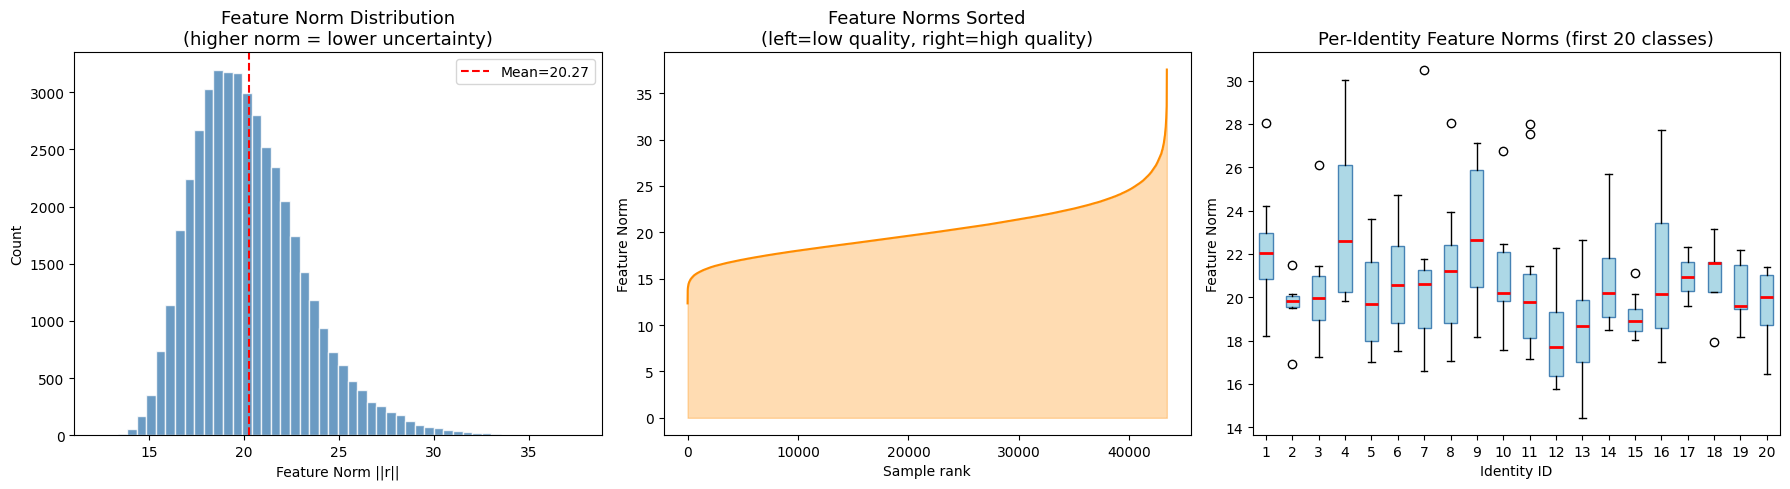

✅ Feature norm analysis saved to feature_norm_analysis.png


In [16]:
# ── Collect feature norms on the validation set ─────────────────────────────
model.eval()
model_device = next(model.parameters()).device

all_norms  = []
all_labels = []
all_embeds = []

with torch.no_grad():
    for v1, _, labels in val_loader:
        v1 = v1.to(model_device)
        r  = model.backbone(v1)                          # (B, 512)
        norms = torch.norm(r, p=2, dim=1).cpu().numpy()  # (B,)
        all_norms.append(norms)
        all_labels.append(labels.numpy())
        all_embeds.append(r.cpu().numpy())

all_norms  = np.concatenate(all_norms)
all_labels = np.concatenate(all_labels)
all_embeds = np.concatenate(all_embeds)

print(f'Validation embeddings collected: {all_embeds.shape}')
print(f'Feature norm — mean: {all_norms.mean():.3f}, std: {all_norms.std():.3f}')
print(f'                min: {all_norms.min():.3f}, max: {all_norms.max():.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram
axes[0].hist(all_norms, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(all_norms.mean(), color='red', linestyle='--', label=f'Mean={all_norms.mean():.2f}')
axes[0].set_title('Feature Norm Distribution\n(higher norm = lower uncertainty)', fontsize=13)
axes[0].set_xlabel('Feature Norm ||r||')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Norm sorted (low quality to high quality)
sorted_norms = np.sort(all_norms)
axes[1].plot(sorted_norms, color='darkorange', linewidth=1.5)
axes[1].fill_between(range(len(sorted_norms)), sorted_norms,
                     alpha=0.3, color='darkorange')
axes[1].set_title('Feature Norms Sorted\n(left=low quality, right=high quality)', fontsize=13)
axes[1].set_xlabel('Sample rank')
axes[1].set_ylabel('Feature Norm')

# 3. Per-class box plot (first 20 classes)
unique_labels = np.unique(all_labels)
n_show = min(20, len(unique_labels))
per_class_norms = [all_norms[all_labels == c] for c in unique_labels[:n_show]]
axes[2].boxplot(per_class_norms, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title(f'Per-Identity Feature Norms (first {n_show} classes)', fontsize=13)
axes[2].set_xlabel('Identity ID')
axes[2].set_ylabel('Feature Norm')

plt.tight_layout()
plt.savefig('feature_norm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature norm analysis saved to feature_norm_analysis.png')

## 18. 🗺️ t-SNE Embedding Visualization

t-SNE reduces 512-dimensional embeddings to 2D for visual inspection.  
Well-separated clusters indicate **good identity discrimination**.

Running t-SNE on 246 samples from 30 identities…


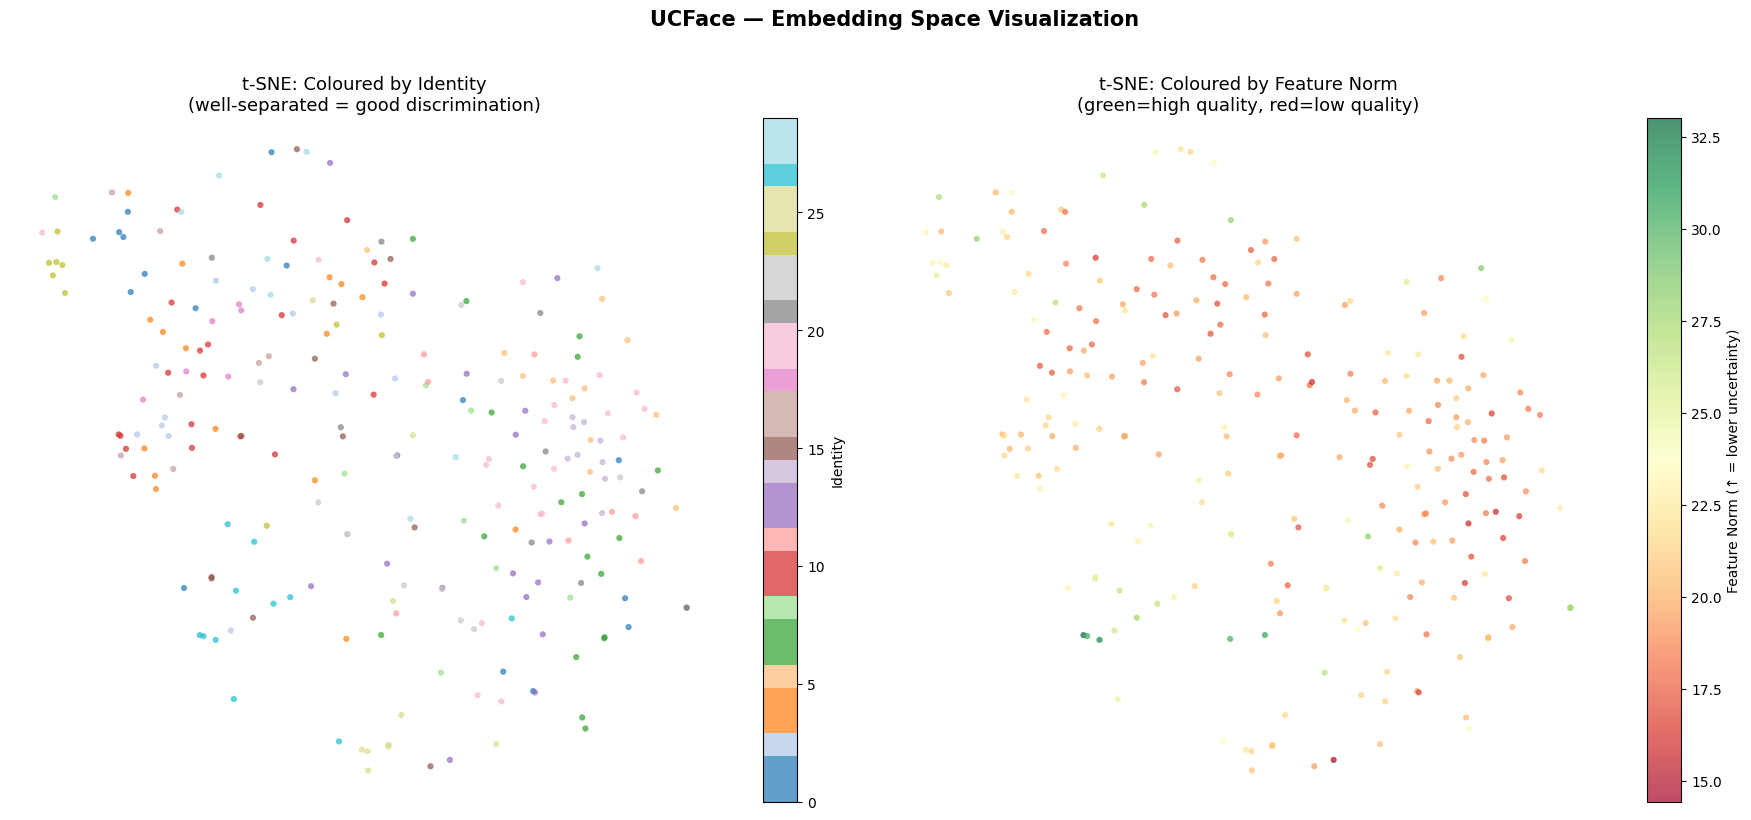

✅ t-SNE visualization saved to tsne_visualization.png


In [17]:
# ── t-SNE ────────────────────────────────────────────────────────────────────
# Use at most 2000 samples and max 30 classes for legibility

N_CLASSES_TSNE = min(30, len(np.unique(all_labels)))
selected_classes = np.unique(all_labels)[:N_CLASSES_TSNE]
mask = np.isin(all_labels, selected_classes)

embeds_sub = all_embeds[mask]
labels_sub = all_labels[mask]
norms_sub  = all_norms[mask]

# Subsample to max 2000 for speed
MAX_SAMPLES = 2000
if len(embeds_sub) > MAX_SAMPLES:
    idx = np.random.choice(len(embeds_sub), MAX_SAMPLES, replace=False)
    embeds_sub = embeds_sub[idx]
    labels_sub = labels_sub[idx]
    norms_sub  = norms_sub[idx]

print(f'Running t-SNE on {len(embeds_sub)} samples from {N_CLASSES_TSNE} identities…')

# L2-normalise before t-SNE (operating on unit sphere)
embeds_norm = sk_normalize(embeds_sub, norm='l2')

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(embeds_sub) // 4),
    n_iter=1000,
    random_state=42,
    learning_rate='auto',
    init='pca',
)
coords = tsne.fit_transform(embeds_norm)   # (N, 2)

# ── Plot 1: coloured by identity ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cmap = plt.get_cmap('tab20', N_CLASSES_TSNE)
scatter1 = axes[0].scatter(
    coords[:, 0], coords[:, 1],
    c=labels_sub, cmap=cmap,
    s=20, alpha=0.7, linewidths=0
)
plt.colorbar(scatter1, ax=axes[0], label='Identity')
axes[0].set_title('t-SNE: Coloured by Identity\n(well-separated = good discrimination)', fontsize=13)
axes[0].set_xlabel('t-SNE dim 1')
axes[0].set_ylabel('t-SNE dim 2')
axes[0].axis('off')

# ── Plot 2: coloured by feature norm ─────────────────────────────────────────
scatter2 = axes[1].scatter(
    coords[:, 0], coords[:, 1],
    c=norms_sub,
    cmap='RdYlGn',      # red=low norm(high uncertainty), green=high norm(low uncertainty)
    s=20, alpha=0.7, linewidths=0
)
plt.colorbar(scatter2, ax=axes[1], label='Feature Norm (↑ = lower uncertainty)')
axes[1].set_title('t-SNE: Coloured by Feature Norm\n(green=high quality, red=low quality)', fontsize=13)
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].axis('off')

plt.suptitle('UCFace — Embedding Space Visualization', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE visualization saved to tsne_visualization.png')

## 19. 🔥 Cosine Similarity Heatmap

Reproduces **Fig. 8 from the paper**: a heatmap of pairwise cosine similarities.  

- **Block-diagonal structure** → good intra-class compactness  
- **Off-diagonal sparsity** → good inter-class separation  
- High-quality images (high norm) → tighter blocks  
- Low-quality images (low norm) → noisier off-diagonal

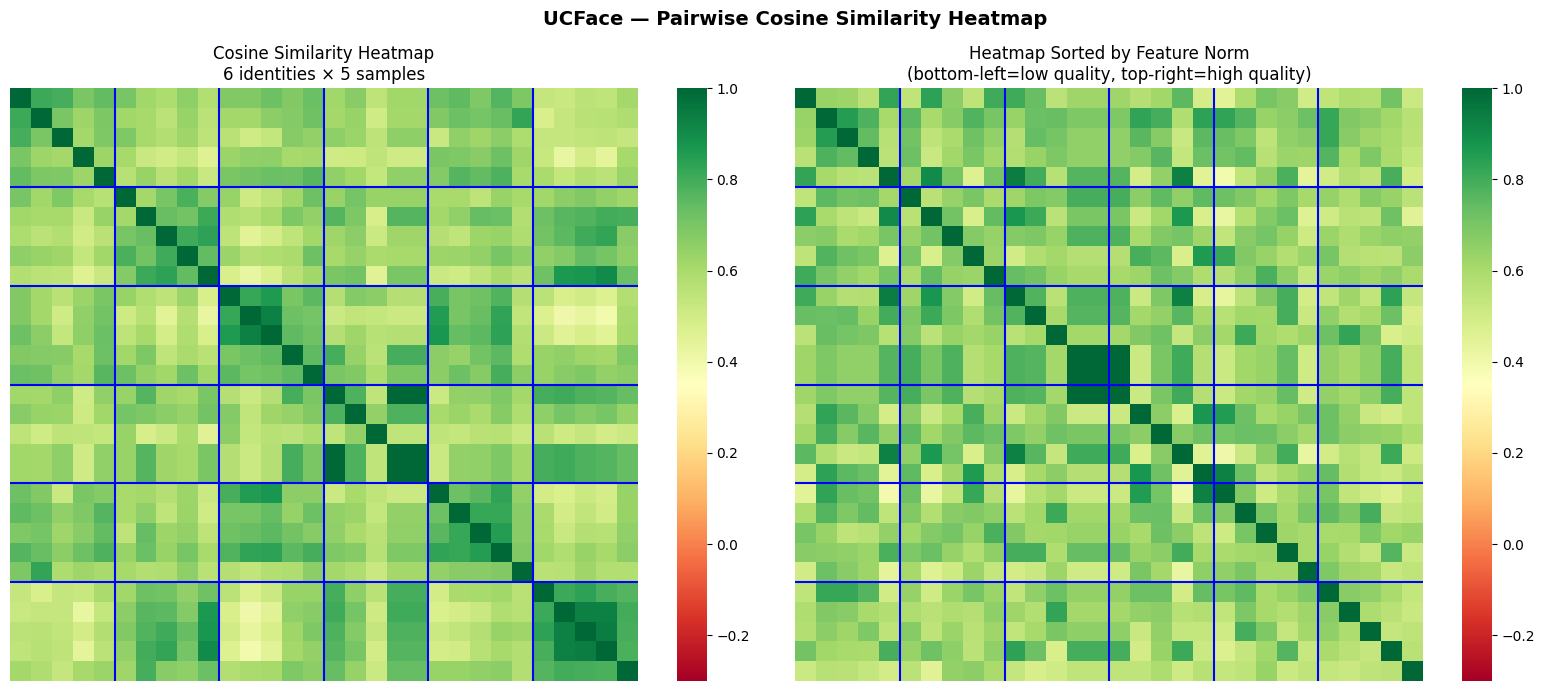

✅ Cosine heatmap saved to cosine_heatmap.png


In [18]:
# ── Select 6 identities × 5 samples = 30 samples for the heatmap ────────────
N_IDS   = 6
N_SAMP  = 5

hm_embeds = []
hm_labels = []

for cls in selected_classes[:N_IDS]:
    idx = np.where(all_labels == cls)[0]
    if len(idx) >= N_SAMP:
        chosen = idx[:N_SAMP]
    else:
        chosen = np.random.choice(idx, N_SAMP, replace=True)
    hm_embeds.append(all_embeds[chosen])
    hm_labels.extend([cls] * N_SAMP)

hm_embeds = np.vstack(hm_embeds)               # (30, 512)
hm_norms  = np.linalg.norm(hm_embeds, axis=1)  # (30,)

# L2-normalise
hm_embeds_norm = hm_embeds / (hm_norms[:, None] + 1e-8)

# Pairwise cosine similarity matrix
cosine_heatmap = hm_embeds_norm @ hm_embeds_norm.T   # (30, 30)

# Sort by norm within each identity to mimic paper's Fig. 8
# (higher norm = lower uncertainty)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_heatmap(ax, mat, title, labels, vmin=-0.3, vmax=1.0):
    sns.heatmap(
        mat,
        ax=ax,
        cmap='RdYlGn',
        vmin=vmin, vmax=vmax,
        xticklabels=False,
        yticklabels=False,
        cbar=True,
        linewidths=0,
    )
    # Draw identity boundary lines
    for i in range(1, N_IDS):
        ax.axhline(i * N_SAMP, color='blue', linewidth=1.5)
        ax.axvline(i * N_SAMP, color='blue', linewidth=1.5)
    ax.set_title(title, fontsize=12)

# High-quality: top half (higher norm samples)
high_q = np.argsort(hm_norms)[::-1][:N_IDS * N_SAMP // 2 * 2]
low_q  = np.argsort(hm_norms)[ :N_IDS * N_SAMP // 2 * 2]

plot_heatmap(axes[0], cosine_heatmap[:N_IDS*N_SAMP, :N_IDS*N_SAMP],
             f'Cosine Similarity Heatmap\n{N_IDS} identities × {N_SAMP} samples',
             hm_labels)

# Separate low vs high norm blocks for insight
sorted_by_norm = np.argsort(hm_norms)
cosine_sorted  = cosine_heatmap[np.ix_(sorted_by_norm, sorted_by_norm)]
plot_heatmap(axes[1], cosine_sorted,
             'Heatmap Sorted by Feature Norm\n(bottom-left=low quality, top-right=high quality)',
             [hm_labels[i] for i in sorted_by_norm])

plt.suptitle('UCFace — Pairwise Cosine Similarity Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cosine_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Cosine heatmap saved to cosine_heatmap.png')

## 20. 🔍 Inference Example

This section demonstrates how to use the trained model for:
1. **Single image embedding** — extract a 512-dim face vector  
2. **Pair verification** — determine if two images show the same person  
3. **Feature norm uncertainty estimate** — gauge image quality

───────────────────────────────────────────────────────
INFERENCE DEMO
───────────────────────────────────────────────────────
Image A embedding norm     : 21.4528
Image A uncertainty proxy  : 0.0466

Same  identity pair: cosine_sim = 0.8086  → same=True
Diff. identity pair: cosine_sim = 0.7621  → same=True
───────────────────────────────────────────────────────


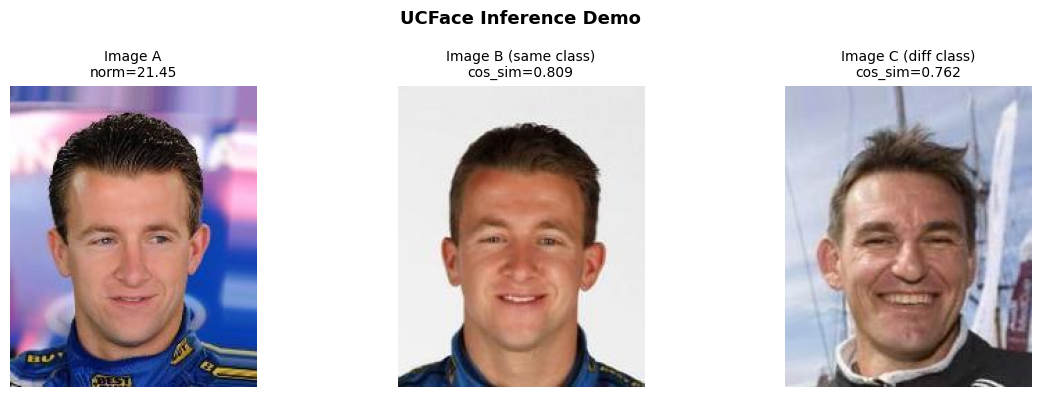

In [19]:
class UCFaceInference:
    """
    Thin wrapper for UCFace inference.

    The projection head is NOT used at inference — only the backbone embedding.
    """

    def __init__(self, model: UCFaceLightningModule, device: str = 'auto'):
        self.model = model
        if device == 'auto':
            self.device = next(model.parameters()).device
        else:
            self.device = torch.device(device)
            self.model.to(self.device)
        self.model.eval()

        self.transform = EVAL_TRANSFORM

    @torch.no_grad()
    def embed(self, image) -> dict:
        """
        Extract embedding from a PIL image or numpy array.

        Returns dict with:
            embedding       : (512,) float32 numpy array
            embedding_norm  : (512,) L2-normalised (for cosine similarity)
            feature_norm    : scalar — image quality proxy
            uncertainty     : 1 / feature_norm — uncertainty score
        """
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image.astype(np.uint8))

        x = self.transform(image).unsqueeze(0).to(self.device)   # (1, 3, H, W)
        r = self.model.backbone(x)                                # (1, 512)
        r = r.squeeze(0).cpu()                                    # (512,)

        feat_norm  = r.norm(p=2).item()
        r_norm     = F.normalize(r, p=2, dim=0).numpy()

        return {
            'embedding'      : r.numpy(),
            'embedding_norm' : r_norm,
            'feature_norm'   : feat_norm,
            'uncertainty'    : 1.0 / (feat_norm + 1e-8),
        }

    def verify(self, img1, img2, threshold: float = 0.4) -> dict:
        """
        Verify whether two face images belong to the same identity.

        Returns dict with:
            same_person  : bool
            cosine_sim   : float (higher = more similar)
            confidence   : min(feature_norm1, feature_norm2) — low norm = less confident
        """
        e1 = self.embed(img1)
        e2 = self.embed(img2)

        cosine_sim = float(np.dot(e1['embedding_norm'], e2['embedding_norm']))

        return {
            'same_person'         : cosine_sim > threshold,
            'cosine_sim'          : cosine_sim,
            'threshold'           : threshold,
            'norm_img1'           : e1['feature_norm'],
            'norm_img2'           : e2['feature_norm'],
            'confidence_proxy'    : min(e1['feature_norm'], e2['feature_norm']),
        }


# ── Demo with synthetic images ────────────────────────────────────────────────
inferencer = UCFaceInference(model)

# Use actual validation images for demo
val_base = ImageFolder(root=str(Path(cfg.DATA_ROOT) / 'val'))

# Load two images of the same identity
img_a_pil, label_a = val_base[0]
img_b_pil, label_b = val_base[1]
img_c_pil, label_c = val_base[-1]   # different identity

# Embed
emb_a = inferencer.embed(img_a_pil)
emb_b = inferencer.embed(img_b_pil)

# Verify: same vs different identity
result_same = inferencer.verify(img_a_pil, img_b_pil)
result_diff = inferencer.verify(img_a_pil, img_c_pil)

print('─' * 55)
print('INFERENCE DEMO')
print('─' * 55)
print(f'Image A embedding norm     : {emb_a["feature_norm"]:.4f}')
print(f'Image A uncertainty proxy  : {emb_a["uncertainty"]:.4f}')
print()
print(f'Same  identity pair: cosine_sim = {result_same["cosine_sim"]:.4f}  '
      f'→ same={result_same["same_person"]}')
print(f'Diff. identity pair: cosine_sim = {result_diff["cosine_sim"]:.4f}  '
      f'→ same={result_diff["same_person"]}')
print('─' * 55)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = [
    f'Image A\nnorm={emb_a["feature_norm"]:.2f}',
    f'Image B (same class)\ncos_sim={result_same["cosine_sim"]:.3f}',
    f'Image C (diff class)\ncos_sim={result_diff["cosine_sim"]:.3f}',
]
for ax, img, title in zip(axes, [img_a_pil, img_b_pil, img_c_pil], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('UCFace Inference Demo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## Bonus: Load from Checkpoint

After training, you can reload the best model from disk.

In [20]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
best_ckpt = checkpoint_callback.best_model_path

if best_ckpt and Path(best_ckpt).exists():
    loaded_model = UCFaceLightningModule.load_from_checkpoint(
        best_ckpt,
        cfg=cfg,
    )
    loaded_model.eval()
    print(f'✅ Loaded best model from: {best_ckpt}')
    inferencer_best = UCFaceInference(loaded_model)
else:
    print('⚠️  No checkpoint found — using current in-memory model.')
    inferencer_best = inferencer

NameError: name 'checkpoint_callback' is not defined

## 21. 🎓 Research Conclusions

### What We Implemented

| Component | Implementation | Paper §|
|---|---|---|
| ArcFace loss | `ArcFaceLoss` — angular margin + scale | §III-B |
| Feature norm uncertainty | `kappa = norm(z).detach()` | §III-C |
| vMF-inspired similarity | `sim = kappa * cosine_sim` | Eq. 16–18 |
| Uncertainty-aware contrastive | `UCFaceContrastiveLoss` (InfoNCE) | Eq. 19 |
| Combined loss | `L_arc + λ * L_uc`, λ=1.0, τ=0.8 | Eq. 20 |

### Key Takeaways

1. **Feature norm as uncertainty**: Images with small feature norms (low quality) have flat vMF distributions → weaker pull/push in contrastive space.  

2. **Stop-gradient on κ**: Without `.detach()`, the model trivially inflates all norms to maximise contrastive similarity — the detach prevents this.  

3. **Add-on design**: UCFace is layered *on top* of ArcFace, not a replacement. This means any ArcFace-style loss (CosFace, AdaFace) can benefit from the UCFace contrastive term.  

4. **Open-set benefit**: Supervised contrastive learning bridges the training–inference discrepancy by learning inter-sample relationships rather than just sample–prototype distances.  

### Future Directions

- Replace vMF with **spherical t-distribution** for better outlier robustness  
- Model uncertainty for **both** anchor and sample (not just anchor)  
- Apply to **video face recognition** (multi-frame fusion via vMF product)

---
*Implementation by M.Tech research student — based on: Ahn et al., IEEE TIFS 2024.*

In [1]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('UCFace Implementation Summary')
print('=' * 60)
print()
print(f'Backbone        : ResNet-50 (pretrained ImageNet)')
print(f'Embedding dim   : {cfg.EMBEDDING_DIM}')
print(f'Projection dim  : {cfg.PROJ_DIM}')
print(f'Num identities  : {cfg.NUM_CLASSES}')
print(f'ArcFace margin  : {cfg.ARC_MARGIN}  scale: {cfg.ARC_SCALE}')
print(f'Temperature τ   : {cfg.TEMPERATURE}')
print(f'Lambda λ        : {cfg.LAMBDA}')
print(f'Optimizer       : Adam (lr={cfg.LR})')
print(f'Scheduler       : CosineAnnealingWarmRestarts')
print(f'Mixed precision : {cfg.PRECISION}')
print()
print('Saved files:')
print('  checkpoints/          — model checkpoints')
print('  logs/                 — TensorBoard logs')
print('  feature_norm_analysis.png')
print('  tsne_visualization.png')
print('  cosine_heatmap.png')
print('  inference_demo.png')
print()
print('To launch TensorBoard:')
print('  %load_ext tensorboard')
print('  %tensorboard --logdir logs/')
print('=' * 60)

UCFace Implementation Summary

Backbone        : ResNet-50 (pretrained ImageNet)


NameError: name 'cfg' is not defined